# **Predicting House Prices with Linear Regression**

### **Objective**

Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.

###**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

###**Load the dataset**

In [ ]:
df = pd.read_csv("House Price Prediction Dataset.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.shape

(2000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [ ]:
df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


###**Check missing values**

In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

###**Explore the target variable**

In [ ]:
df["Price"].describe()

,Price
count,2000.000000
mean,537676.855000
std,276428.845719
min,50005.000000
25%,300098.000000
50%,539254.000000
75%,780086.000000
max,999656.000000


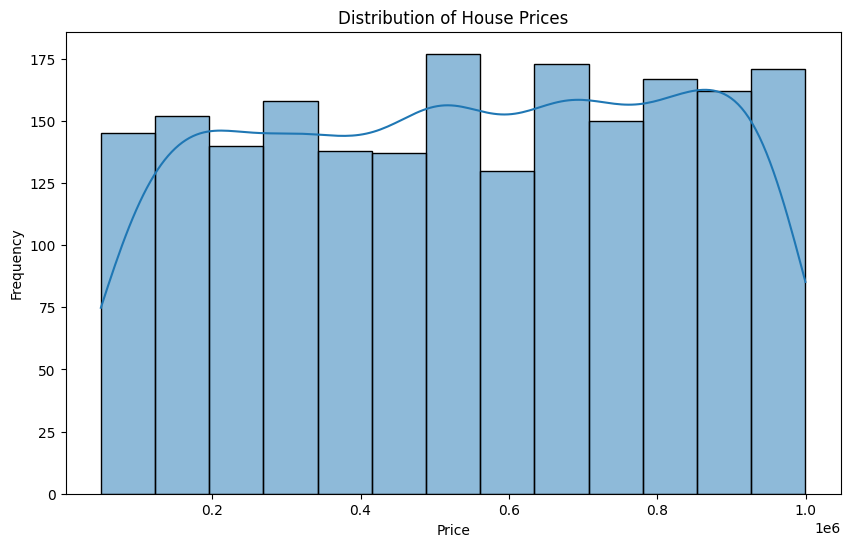

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### **Feature Selection**

The following features were considered as potential predictors of house price:

- **Area:** It is generally the case that larger properties command higher prices.
- The number of bedrooms can have an effect on both the value and the size of a property.
- **Bathrooms:** The market value of properties can be higher if they have more bathrooms.
- **Floors:** The number of floors can tell you something about the size and structure of the property.
- **YearBuilt:** The price of a property can be influenced by its age.
– Location plays an important role in setting property prices.
– The condition of a property has an effect on its market value.
- **Garage:** The presence or absence of a garage can have an impact on the appeal and value of a house.

The Id column cannot serve as a predictor since it functions only as an identifier and does not stand for any significant attribute of the property.

The variable that this project is focusing on is **Price**, and the model will use the selected features to predict it.

###**Categorical variables**

In [ ]:
df["Location"].value_counts()

,count
Location,
Downtown,558
Urban,485
Suburban,483
Rural,474


In [ ]:
df["Condition"].value_counts()

,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461


In [ ]:
df["Garage"].value_counts()

,count
Garage,
No,1038
Yes,962


###**Correlation analysis**

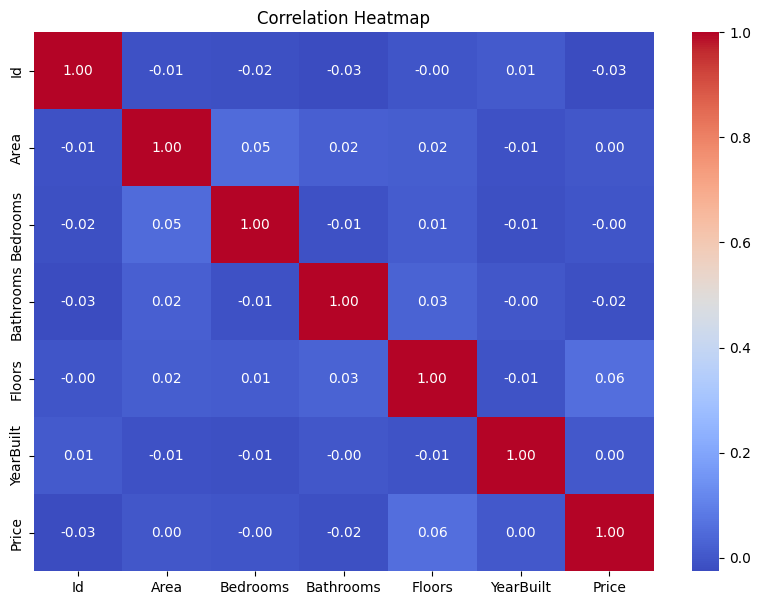

In [ ]:
plt.figure(figsize=(10, 7))
correlation = df.select_dtypes(include=np.number).corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

###**Prepare X and y**

We now separate:

X = predictors

y = target

In [ ]:
X = df.drop(columns=["Price", "Id"])
y = df["Price"]

###**Identifying numerical and categorical columns**

In [ ]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

print("Categorical Features:", list(categorical_features))
print("Numerical Features:", list(numerical_features))

Categorical Features: ['Location', 'Condition', 'Garage']
Numerical Features: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']


###**One-Hot Encoding**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

###**Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 8)
Testing data: (400, 8)


###**Build the Linear Regression model**

In [ ]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Location', 'Condition', 'Garage'], dtype='object'))])),
                ('regressor', LinearRegression())])

###**Make predictions**

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512 521375.92025826 523320.18080583 578133.64353335
 545899.64738458 577368.69940644]


###**Evaluate the model**

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 78321466146.0328
Root Mean Squared Error (RMSE): 279859.72583784326
R² Score: -0.006717808430749761


###**Actual vs Predicted Prices**

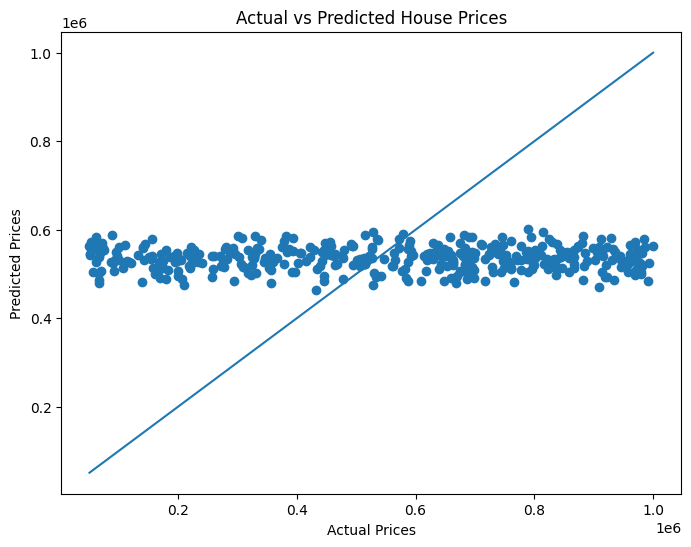

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [ ]:
df.select_dtypes(include=np.number).corr()["Price"].sort_values(ascending=False)

,Price
Price,1.000000
Floors,0.055890
YearBuilt,0.004845
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737
Id,-0.025643


In [ ]:
df.head(10)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [ ]:
print("Average Price by Location:")
print(df.groupby("Location")["Price"].mean().sort_values(ascending=False))

Average Price by Location:
Location
Suburban    557416.333333
Rural       538613.943038
Downtown    536059.661290
Urban       518963.548454
Name: Price, dtype: float64


In [ ]:
print("\nAverage Price by Condition:")
print(df.groupby("Condition")["Price"].mean().sort_values(ascending=False))


Average Price by Condition:
Condition
Fair         560594.140115
Excellent    530812.009785
Good         529002.351410
Poor         528933.218935
Name: Price, dtype: float64


In [ ]:
print("\nAverage Price by Garage:")
print(df.groupby("Garage")["Price"].mean().sort_values(ascending=False))


Average Price by Garage:
Garage
Yes    538492.747401
No     536920.700385
Name: Price, dtype: float64


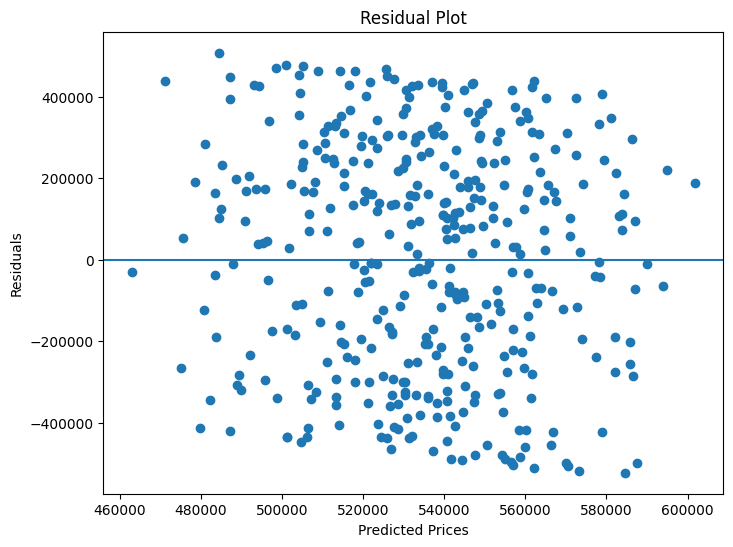

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

###**Residual Plot**

In [ ]:
residuals = y_test - y_pred

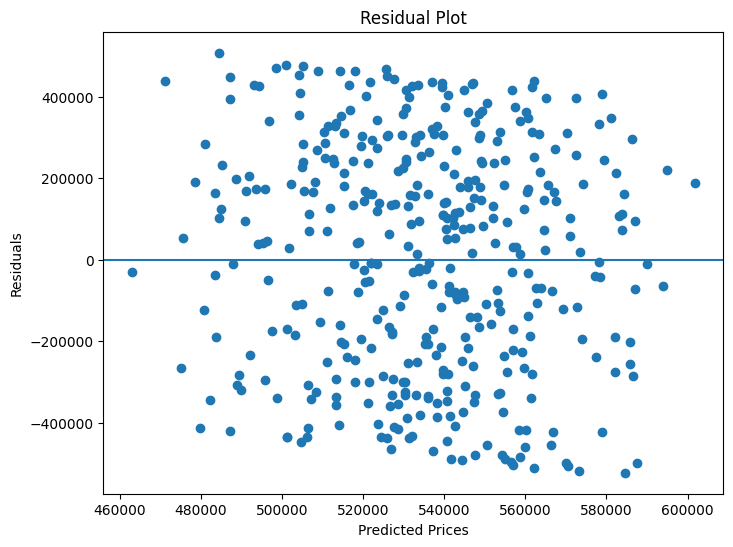

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

###**Coefficient analysis**

In [ ]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)
coef_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
13,remainder__Floors,23727.983633,23727.983633
5,categorical__Condition_Fair,20279.424861,20279.424861
6,categorical__Condition_Good,-16744.927821,16744.927821
3,categorical__Location_Urban,-12746.572142,12746.572142
2,categorical__Location_Suburban,11484.336584,11484.336584
12,remainder__Bathrooms,-9662.248234,9662.248234
4,categorical__Condition_Excellent,-3803.882985,3803.882985
1,categorical__Location_Rural,1289.888789,1289.888789
8,categorical__Garage_No,-1186.765289,1186.765289
9,categorical__Garage_Yes,1186.765289,1186.765289


###**Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MSE: 78321066392.83418
Ridge RMSE: 279859.0116341337
Ridge R²: -0.006712670137458687


###**Final comparison table**

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,7.832147e+10,279859.725838,-0.006718
1,Ridge Regression,7.832107e+10,279859.011634,-0.006713


### Conclusion

For this project, a Linear Regression model was built to predict house prices based on features such as Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition and Garage.

The dataset was analyzed and preprocessed by checking for missing values and encoded categorical features with one-hot encoding. The data was then partitioned into training and testing set with 80/20 split.

The results of Linear Regression model are as follow:

- **Mean Square Error (MSE):** 78,321,466,146.03

- **Root Mean Squared Error (RMSE):** 279859.73

- **R2 Score: -0.0067
The negative R-squared value indicates that the Linear Regression model was not a good model for this data set and had little predictive value over a simple baseline average house price.

Correlation analysis also indicated very weak linear relationships between the numerical features and the target variable, Price. The residual plot also showed a wide spread of errors around the zero line which further indicated that the model was unable to capture the relationship between the available features and house prices effectively.

To summarize, this project was a hands-on learning opportunity for Exploratory Data Analysis, feature selection, categorical encoding, train-test split, Linear Regression, model evaluation, and residual analysis. The results also show the significance of comprehending the quality and predictive relationships within a dataset before building a machine learning model.
